# Notebook 05 - CLV Prediction (Regression)

**Input:** `data/processed/customer_segments.parquet` (5,265 customers x 45 columns)

**Output:**
- `data/processed/clv_predictions.parquet` - each customer with their predicted 90-day revenue
- `models/clv_xgboost.joblib` - the trained model for later use in the API
- `reports/figures/clv_*.png` - Visualization for the boss pitch

## What we're doing and why

We're training a supervised regression model to predict **how much each customer will generate in the next 90 days**, given their behavior up to the snapshot date.

This is the project's first "real" ML model. Everything before was preparation; from here on, we're using the features to make actual predictions about the future.

## The target shape is unusual - this matters

Looking at `target_revenue_90d`:
- **56.5% of customers have target = £0** (they didn't repurchase in the window)
- **The max is £168,470** while the median is £0

This is **zero-inflated, right-skewed target**. Two consequences:
1. **We log-transform the target** so the model sees a more normal distribution
2. **We evaluate on ranking, not just absolute accuracy** - business cares about identifying *which* customers will spend, not predicting exact pounds.

## Why XGBoost
- Handles non-linear feature interaction automatically
- Robust to outliers and skewed features
- Doesn't require feature scaling
- Industry-standard for tabular data - what boss/manager expects to see
- SHAP intergration for explainability ("why did the model predict £247 for this customer?")

## Notebook structure:
1. Load and prepare features + target
2. Train/validation split (with stratification on the zero target)
3. Baseline model (so we know what "good" looks like)
4. XGBoost training
5. Eveluation - regresion metrics AND ranking metrics
6. Lift chart (the business-facing accuracy measure)
7. Feature importance with SHAP
8. Individual customer explanations
9. Save prediction and model

## Setup

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
import xgboost as xgb
import shap

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
REPORTS_DIR = Path('../reports/figures')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE=42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Loaded 5,256 customers x 45 columns


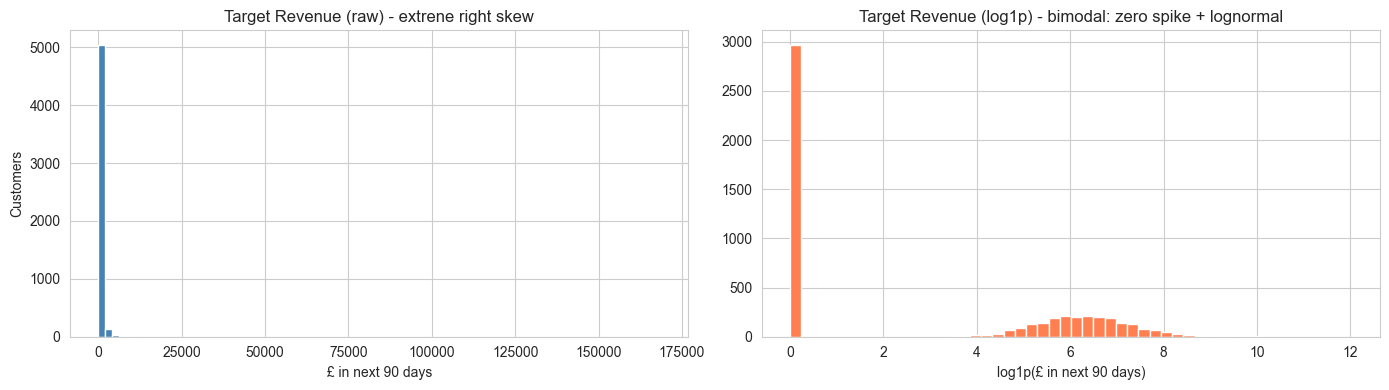


Zero-revenue customers: 2,967 (56.4%)


In [3]:
df = pd.read_parquet(PROCESSED_DIR / 'customer_segments.parquet')
print(f'Loaded {len(df):,} customers x {df.shape[1]} columns')

# Look at the target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['target_revenue_90d'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Target Revenue (raw) - extrene right skew')
axes[0].set_xlabel('£ in next 90 days')
axes[0].set_ylabel('Customers')

# Log-transformed view
log_target = np.log1p(df['target_revenue_90d'])
axes[1].hist(log_target, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Target Revenue (log1p) - bimodal: zero spike + lognormal')
axes[1].set_xlabel('log1p(£ in next 90 days)')
plt.tight_layout()
plt.show()

print(f'\nZero-revenue customers: {(df["target_revenue_90d"] == 0).sum():,} ({(df["target_revenue_90d"] == 0).mean()*100:.1f}%)')

**Reading the plots:**
- Left: raw target - a tiny number of mega-customers visually dominate. Useless distribution shape for modeling.
- Right: log1p-transformed target - clearly bimodal. The big spike at log1p(0)=0 is churned customers. The bulge to the right is the actual revenue distribution among repeat buyers.

**Why this matters:** Linear models would fail badly on the raw target. Tree models (XGBoost) handle it better but still benefit from log-transform<br> because it stabilizes the loss surface and prevents whales from dominating gradient updates.